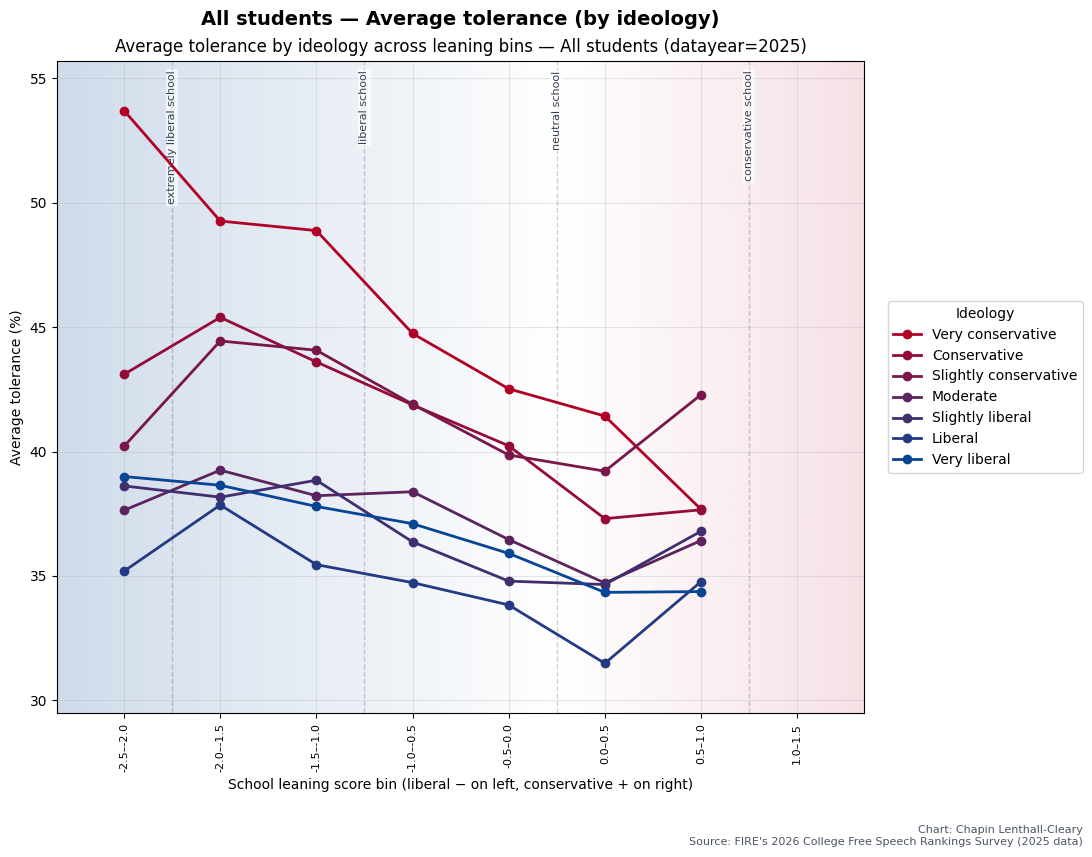

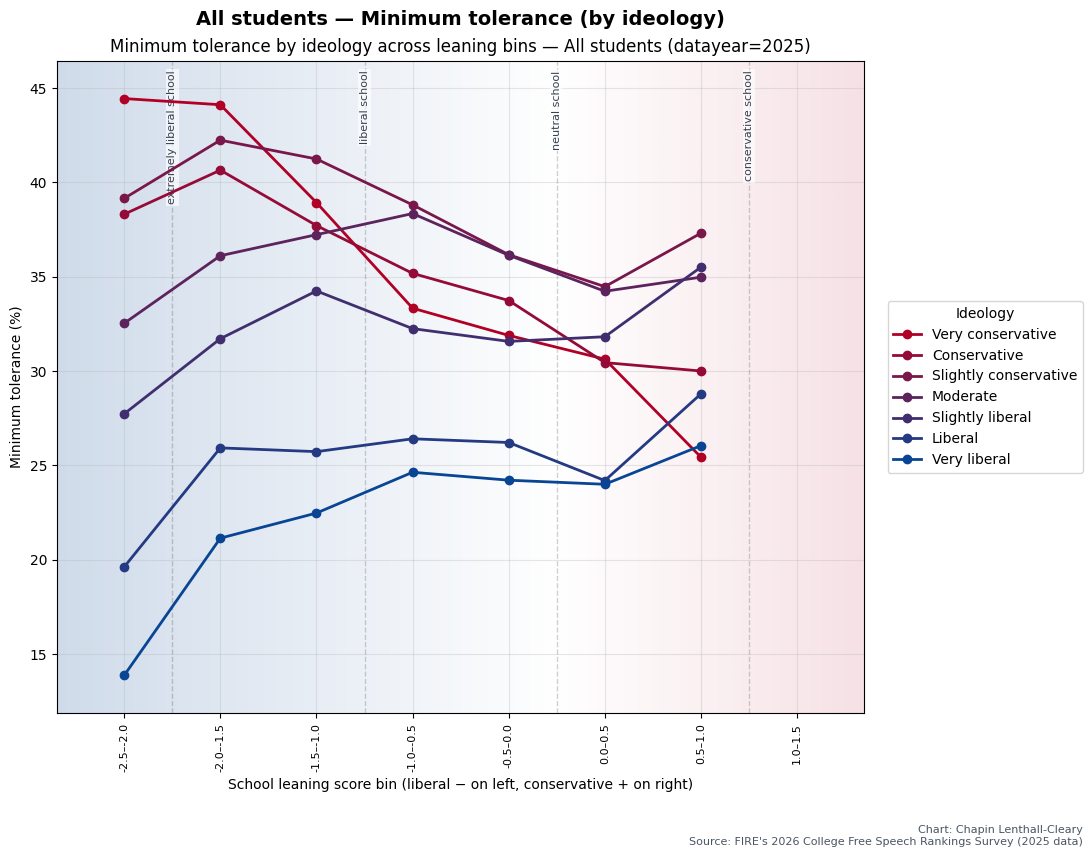

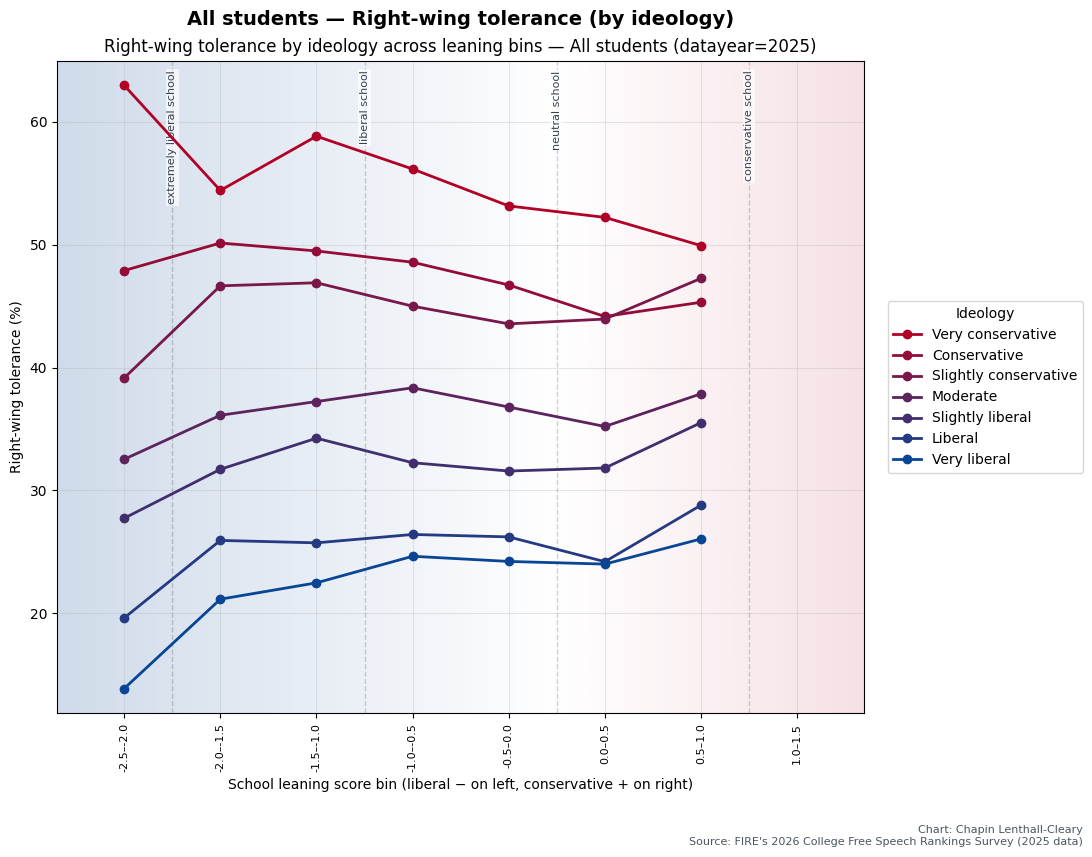

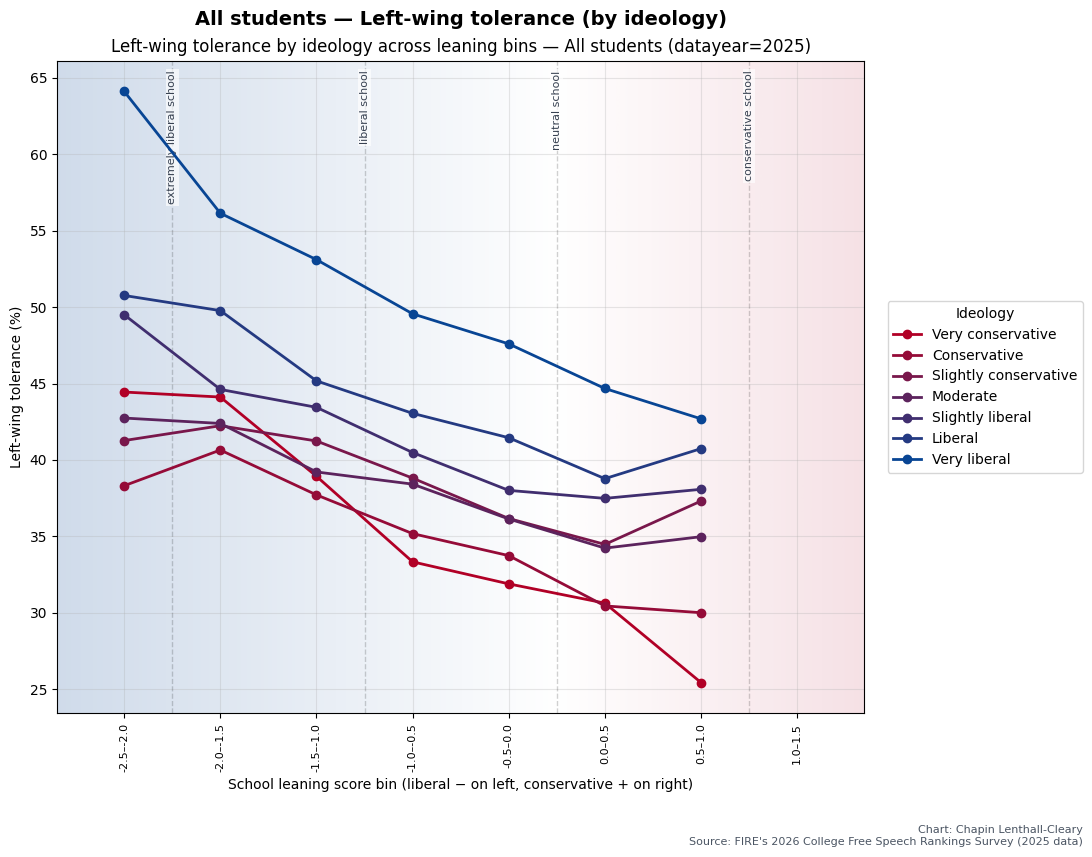

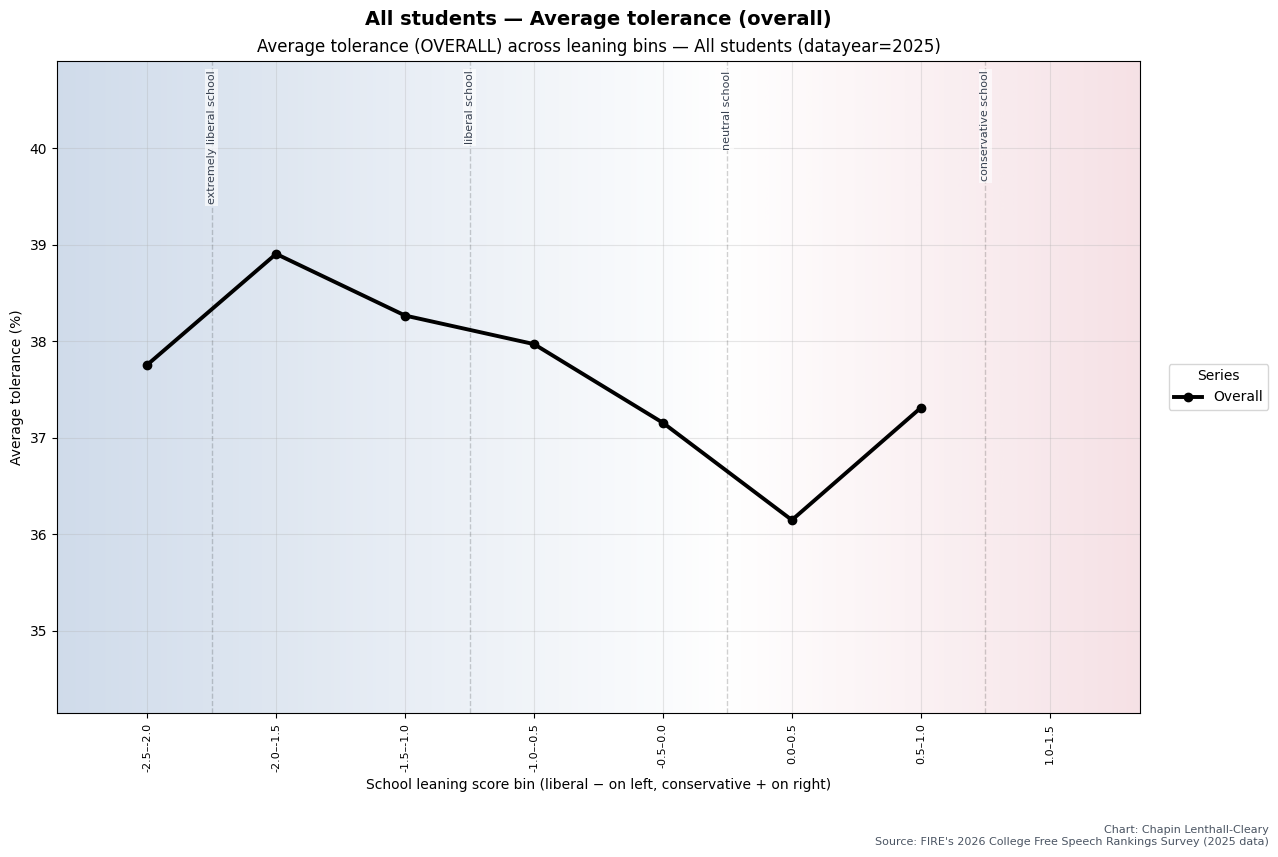

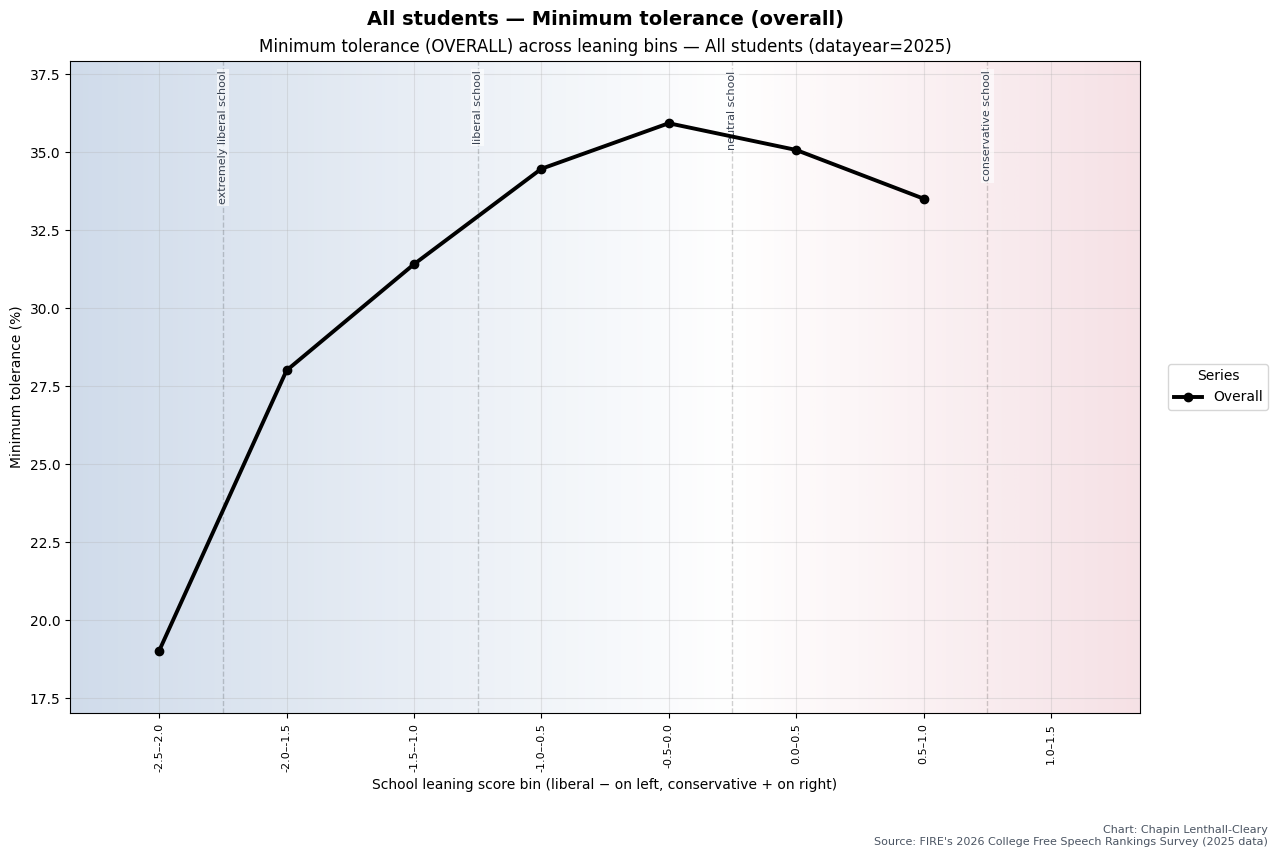

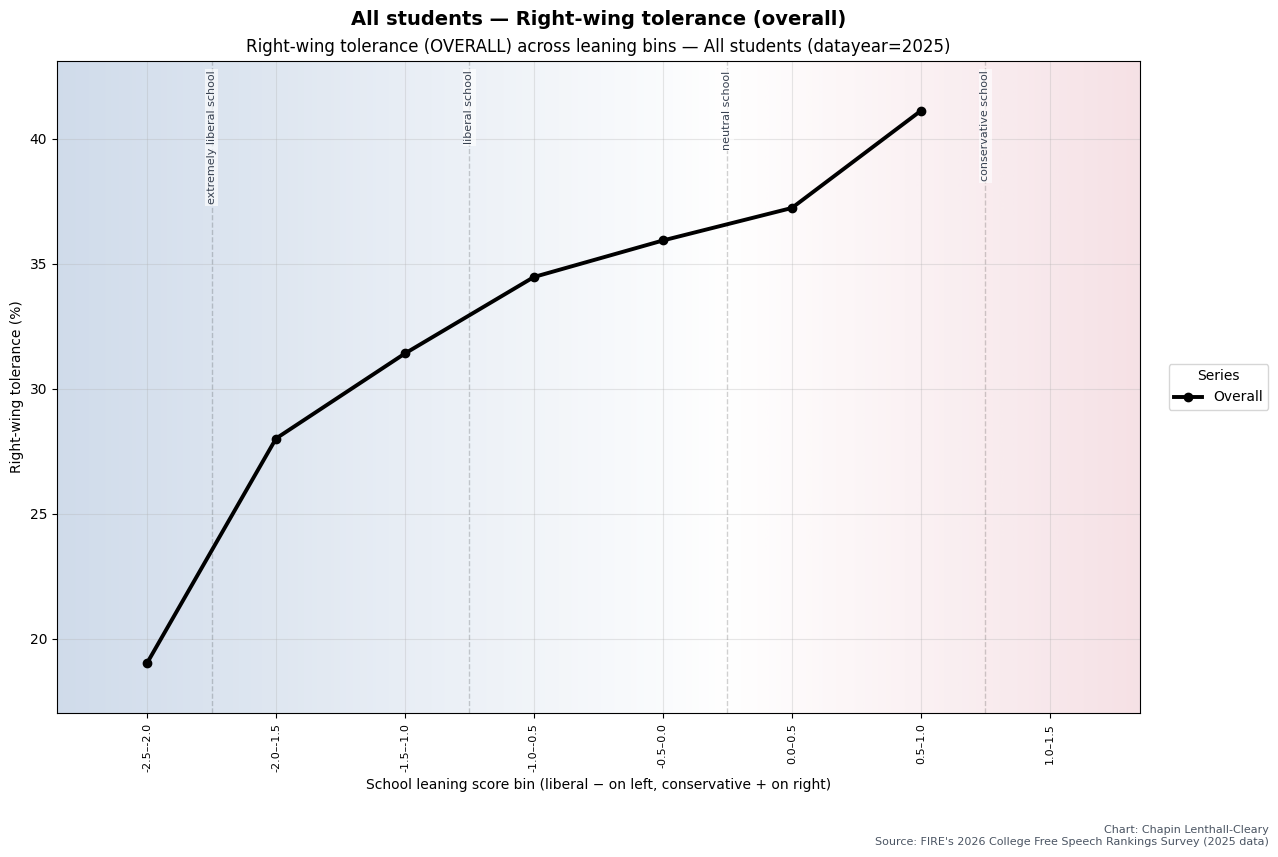

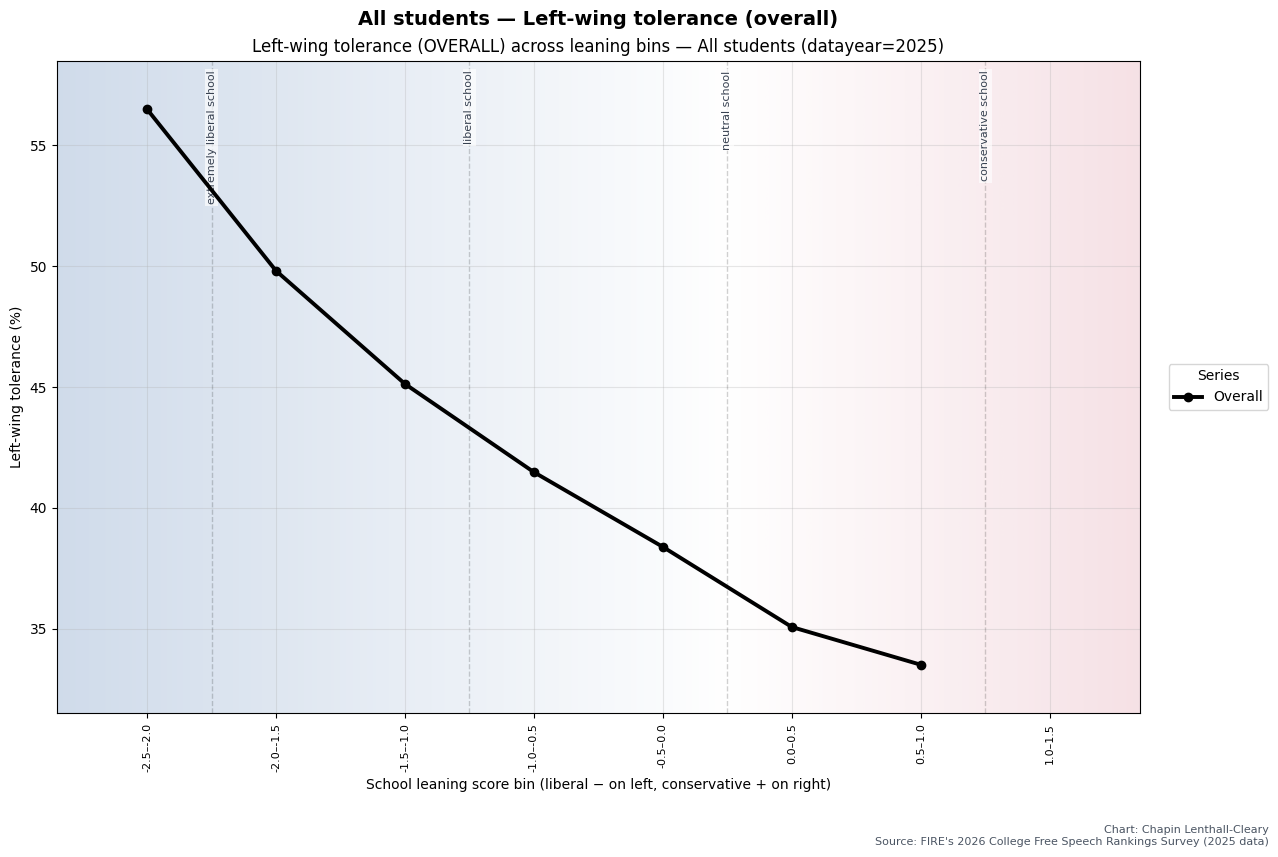

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.legend import Legend
from pathlib import Path
from typing import Dict, List, Tuple, Optional

# -----------------
# Config
# -----------------
CSV_PATH    = Path("cfsrALL_24_25.csv")
YEAR_COL    = "datayear"
YEAR        = 2025  # set to None to use all years

SCHOOL_COL  = "schoolname"
IDEO_COL    = "ideo"
GENDER_COL  = "gender_bin"  # kept for compatibility; we do NOT split by gender anymore

RIGHT_TRIAD = ["spk_abortion", "spk_trans", "spk_blm"]
LEFT_TRIAD  = ["spk_cathped", "spk_policekkk", "spk_kidtrans"]

BIN_WIDTH = 0.5
IDEO_MODE = "bucket"   # "bucket" or "code"

# Axis buffers (in axis units)
X_BUFFER = 0.10   # leaning score units
Y_BUFFER = 2.00   # tolerance % points

# What to generate (All students only)
MAKE_IDEOLOGY_PLOTS = True  # 4 plots: ideology-colored lines
MAKE_OVERALL_PLOTS  = True  # +4 plots: overall-only single line (separate figures)

# Bigger charts
FIGSIZE_IDEOLOGY = (15, 9)
FIGSIZE_OVERALL  = (15, 9)

# Suptitle + credits
CREDITS_TEXT = (
    "Chart: Chapin Lenthall-Cleary\n"
    f"Source: FIRE's 2026 College Free Speech Rankings Survey ({YEAR if YEAR is not None else 'all years'} data)"
)
CREDITS_COLOR = "#4b5563"

# Tighter spacing (still leaves room for rotated bin-range tick labels)
SUPTITLE_Y = 0.965
CREDITS_Y  = 0.035

# Tight layout rects: [left, bottom, right, top]
# (right leaves room for legend)
RECT_IDEO    = [0.06, 0.08, 0.80, 0.95]
RECT_OVERALL = [0.06, 0.08, 0.92, 0.95]

# Background gradient opacity
BG_ALPHA = 0.22
# -----------------

# NOTE: Ideology weights (unchanged), but we INVERT the school leaning score so:
#   liberal schools -> negative (left), conservative schools -> positive (right)
IDEO_WEIGHTS = {1: 3, 2: 2, 3: 1, 4: 0, 5: -1, 6: -2, 7: -3, 8: 3, 9: 0}

BUCKET_MAP = {
    1: "Very liberal",
    2: "Liberal",
    3: "Slightly liberal",
    4: "Moderate",
    5: "Slightly conservative",
    6: "Conservative",
    7: "Very conservative",
    8: "Very liberal",  # Dem Soc
    9: "Moderate",      # Libertarian
}
BUCKET_ORDER = [
    "Very conservative",
    "Conservative",
    "Slightly conservative",
    "Moderate",
    "Slightly liberal",
    "Liberal",
    "Very liberal",
]
BUCKET_SCORE = {
    "Very conservative": -3,
    "Conservative": -2,
    "Slightly conservative": -1,
    "Moderate": 0,
    "Slightly liberal": 1,
    "Liberal": 2,
    "Very liberal": 3,
}

# Red → Blue gradient for ideology LINES (red=conservative, blue=liberal)
CMAP_R2B = LinearSegmentedColormap.from_list("red_to_blue", ["#b10026", "#084594"])

# Blue → White → Red background for SCHOOL leaning ( -3=blue, 0=white, +3=red )
CMAP_BWR = LinearSegmentedColormap.from_list("blue_white_red", ["#084594", "#ffffff", "#b10026"])

# Reference labels for school leaning (only if within x-limits)
LEANING_REF_LABELS = [
    (-2, "extremely liberal school"),
    (-1, "liberal school"),
    (0,  "neutral school"),
    (1,  "conservative school"),
    (2,  "extremely conservative school"),
]


# -----------------
# Layout helpers
# -----------------
def place_suptitle_over_axes(fig: plt.Figure, ax: plt.Axes, suptitle: str) -> None:
    """
    Center the suptitle over the *axes* (plot area), not the whole figure
    (so it ignores the extra legend column).
    Call this AFTER tight_layout so ax.get_position() is final.
    """
    bbox = ax.get_position()
    x_center = float((bbox.x0 + bbox.x1) / 2.0)
    fig.suptitle(suptitle, fontsize=14, fontweight="bold", x=x_center, y=SUPTITLE_Y)


def add_credits_aligned_to_legend(
    fig: plt.Figure,
    legend: Optional[Legend],
    x_fallback: float,
) -> None:
    """
    Place credits so their RIGHT EDGE is not farther right than the legend's RIGHT EDGE.
    If no legend exists, align to x_fallback.
    """
    x = x_fallback

    if legend is not None:
        fig.canvas.draw()
        renderer = fig.canvas.get_renderer()
        bbox_disp = legend.get_window_extent(renderer=renderer)
        bbox_fig = bbox_disp.transformed(fig.transFigure.inverted())
        x = min(0.99, float(bbox_fig.x1))

    fig.text(
        x, CREDITS_Y, CREDITS_TEXT,
        ha="right", va="bottom", fontsize=8, color=CREDITS_COLOR
    )


def add_leaning_background_gradient(ax, xlim_min: float, xlim_max: float, alpha: float = BG_ALPHA) -> None:
    """Left->right gradient keyed to school leaning score: -3 blue, 0 white, +3 red."""
    ymin, ymax = ax.get_ylim()
    xs = np.linspace(xlim_min, xlim_max, 512)
    Z = np.tile(xs, (2, 1))
    ax.imshow(
        Z,
        extent=[xlim_min, xlim_max, ymin, ymax],
        aspect="auto",
        origin="lower",
        cmap=CMAP_BWR,
        vmin=-3, vmax=3,
        alpha=alpha,
        zorder=0,
    )


def add_leaning_reference_labels(ax, xlim_min: float, xlim_max: float) -> None:
    """Vertical reference lines + labels at x = -2,-1,0,1,2 if within view."""
    for x, label in LEANING_REF_LABELS:
        if xlim_min <= x <= xlim_max:
            ax.axvline(x, color="black", alpha=0.18, linestyle="--", linewidth=1.0, zorder=1)
            ax.text(
                x, 0.985, label,
                transform=ax.get_xaxis_transform(),
                ha="center", va="top",
                fontsize=8, color="#374151",
                rotation=90,
                bbox=dict(facecolor="white", edgecolor="none", alpha=0.65, pad=1.0),
                zorder=2,
            )


# -----------------
# Data helpers
# -----------------
def scale_sum_to_pct(sum_series: pd.Series, k: int) -> pd.Series:
    """Maps sum in [k, 4k] to percent in [0, 100]."""
    return (sum_series - k) / (3 * k) * 100.0


def compute_school_leaning(df: pd.DataFrame) -> pd.DataFrame:
    """
    Computes school leaning score, then INVERTS it so:
      liberal schools are NEGATIVE (left), conservative schools are POSITIVE (right).
    """
    d = df[[SCHOOL_COL, IDEO_COL]].copy()
    d[IDEO_COL] = pd.to_numeric(d[IDEO_COL], errors="coerce")
    d = d.loc[d[IDEO_COL].between(1, 9, inclusive="both")].copy()
    if d.empty:
        raise ValueError("No valid ideology responses (1–9) to compute leaning_score.")

    d["ideo_int"] = d[IDEO_COL].astype(int)
    d["weight"] = d["ideo_int"].map(IDEO_WEIGHTS).astype(float)

    grp = d.groupby(SCHOOL_COL, dropna=True)
    leaning = (grp["weight"].sum() / grp["weight"].size()).rename("leaning_score")

    # INVERT: liberal -> negative; conservative -> positive
    leaning = (-1.0 * leaning).rename("leaning_score")

    return leaning.reset_index()


def compute_bin_edges(scores: pd.Series, width: float) -> np.ndarray:
    s = pd.to_numeric(scores, errors="coerce")
    s = s[np.isfinite(s)]
    if s.empty:
        raise ValueError("No valid leaning_score values for binning.")
    start = np.floor(s.min() / width) * width
    end   = np.ceil(s.max() / width) * width + width  # include max with right=False
    edges = np.arange(start, end + 1e-12, width)
    if len(edges) < 2:
        raise ValueError("Binning failed (not enough edges).")
    return edges


def build_student_tolerance(df: pd.DataFrame) -> pd.DataFrame:
    cols_needed = [SCHOOL_COL, IDEO_COL, GENDER_COL] + RIGHT_TRIAD + LEFT_TRIAD
    for c in cols_needed:
        if c not in df.columns:
            raise ValueError(f"Missing column '{c}'.")

    d = df[cols_needed].copy()

    for c in [IDEO_COL, GENDER_COL] + RIGHT_TRIAD + LEFT_TRIAD:
        d[c] = pd.to_numeric(d[c], errors="coerce")

    valid_ideo = d[IDEO_COL].between(1, 9, inclusive="both")
    valid_tol  = d[RIGHT_TRIAD + LEFT_TRIAD].ge(1).all(axis=1) & d[RIGHT_TRIAD + LEFT_TRIAD].le(4).all(axis=1)
    d = d.loc[valid_ideo & valid_tol].copy()
    if d.empty:
        return pd.DataFrame(columns=[SCHOOL_COL, "ideo_int", GENDER_COL, "right_pct", "left_pct"])

    d["ideo_int"] = d[IDEO_COL].astype(int)
    k = len(RIGHT_TRIAD)  # 3
    d["right_pct"] = scale_sum_to_pct(d[RIGHT_TRIAD].sum(axis=1), k)
    d["left_pct"]  = scale_sum_to_pct(d[LEFT_TRIAD].sum(axis=1),  k)

    return d[[SCHOOL_COL, "ideo_int", GENDER_COL, "right_pct", "left_pct"]]


def ideology_order_and_colors(ideo_mode: str) -> Tuple[List[str], Dict[str, tuple]]:
    if ideo_mode == "bucket":
        order = BUCKET_ORDER[:]
        score_map = BUCKET_SCORE.copy()
    elif ideo_mode == "code":
        score_map = {str(i): int(IDEO_WEIGHTS[i]) for i in range(1, 10)}  # -3..+3
        order = sorted(score_map.keys(), key=lambda k: (score_map[k], int(k)))  # conservative->liberal
    else:
        raise ValueError("IDEO_MODE must be 'bucket' or 'code'.")

    def score_to_color(score: float):
        # score in [-3,+3] -> t in [0,1]: -3=red, +3=blue
        t = (score + 3.0) / 6.0
        return CMAP_R2B(max(0.0, min(1.0, t)))

    colors = {g: score_to_color(score_map[g]) for g in order}
    return order, colors


def set_y_limits_with_buffer(ax, values: np.ndarray, y_buffer: float):
    y = pd.to_numeric(pd.Series(values.ravel()), errors="coerce").to_numpy()
    y = y[np.isfinite(y)]
    if y.size == 0:
        return
    ymin, ymax = float(y.min()), float(y.max())
    if ymin == ymax:
        ymin -= y_buffer
        ymax += y_buffer
    else:
        ymin -= y_buffer
        ymax += y_buffer
    ax.set_ylim(max(-5, ymin), min(105, ymax))


def _fmt_edge(x: float) -> str:
    # avoid "-0.0"
    if abs(x) < 1e-9:
        x = 0.0
    return f"{x:.1f}"


def make_bin_range_labels(edges: np.ndarray) -> List[str]:
    # Example: -2.5–-2.0 (en dash)
    return [f"{_fmt_edge(edges[i])}–{_fmt_edge(edges[i+1])}" for i in range(len(edges) - 1)]


# -----------------
# Plotters
# -----------------
def plot_ideology_metric(
    wide: pd.DataFrame,
    order: List[str],
    colors: Dict[str, tuple],
    suptitle: str,
    title: str,
    ylabel: str,
    x_ticks: np.ndarray,
    x_ticklabels: List[str],
    xlim_min: float,
    xlim_max: float,
):
    fig, ax = plt.subplots(figsize=FIGSIZE_IDEOLOGY)
    ax.set_axisbelow(True)

    wide = wide.reindex(index=x_ticks)

    any_line = False
    for g in order:
        if g not in wide.columns:
            continue
        y = wide[g]
        if not y.notna().any():
            continue
        any_line = True
        ax.plot(wide.index, y, marker="o", linewidth=2.0, color=colors[g], label=str(g), zorder=3)

    # OLD title stays on axes
    ax.set_title(title, pad=6)

    ax.set_xlabel("School leaning score bin (liberal − on left, conservative + on right)")
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3, zorder=2)

    ax.set_xlim(xlim_min, xlim_max)
    ax.set_xticks(x_ticks)
    ax.set_xticklabels(x_ticklabels, rotation=90, fontsize=8)

    # y zoom to plotted data (+ buffer)
    set_y_limits_with_buffer(ax, wide.to_numpy(), Y_BUFFER)

    # background + reference labels (needs limits set)
    add_leaning_background_gradient(ax, xlim_min, xlim_max, alpha=BG_ALPHA)
    add_leaning_reference_labels(ax, xlim_min, xlim_max)

    leg = None
    if any_line:
        leg = ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), title="Ideology")

    # layout first, then place suptitle centered over axes
    fig.tight_layout(rect=RECT_IDEO)
    place_suptitle_over_axes(fig, ax, suptitle)
    add_credits_aligned_to_legend(fig, leg, x_fallback=RECT_IDEO[2])
    plt.show()


def plot_overall_metric(
    overall_y: pd.Series,
    suptitle: str,
    title: str,
    ylabel: str,
    x_ticks: np.ndarray,
    x_ticklabels: List[str],
    xlim_min: float,
    xlim_max: float,
):
    fig, ax = plt.subplots(figsize=FIGSIZE_OVERALL)
    ax.set_axisbelow(True)

    y = pd.to_numeric(overall_y, errors="coerce").reindex(x_ticks)

    if y.notna().any():
        ax.plot(x_ticks, y.values, marker="o", linewidth=2.8, color="black", label="Overall", zorder=4)
        set_y_limits_with_buffer(ax, y.to_numpy().reshape(-1, 1), Y_BUFFER)

    # OLD title stays on axes
    ax.set_title(title, pad=6)

    ax.set_xlabel("School leaning score bin (liberal − on left, conservative + on right)")
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3, zorder=2)

    ax.set_xlim(xlim_min, xlim_max)
    ax.set_xticks(x_ticks)
    ax.set_xticklabels(x_ticklabels, rotation=90, fontsize=8)

    add_leaning_background_gradient(ax, xlim_min, xlim_max, alpha=BG_ALPHA)
    add_leaning_reference_labels(ax, xlim_min, xlim_max)

    leg = None
    if y.notna().any():
        leg = ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), title="Series")

    fig.tight_layout(rect=RECT_OVERALL)
    place_suptitle_over_axes(fig, ax, suptitle)
    add_credits_aligned_to_legend(fig, leg, x_fallback=RECT_OVERALL[2])
    plt.show()


def make_plots_for_all_students(stu: pd.DataFrame, edges: np.ndarray):
    if stu.empty:
        print("[SKIP] No data for All students.")
        return

    work = stu.copy()

    # ideology group (line identity)
    if IDEO_MODE == "bucket":
        work["ideo_group"] = work["ideo_int"].map(BUCKET_MAP)
        work = work[work["ideo_group"].notna()].copy()
        work["ideo_group"] = pd.Categorical(work["ideo_group"], categories=BUCKET_ORDER, ordered=True)
    else:
        work["ideo_group"] = work["ideo_int"].astype(int).astype(str)

    # binning (midpoints)
    work["lean_bin"] = pd.cut(work["leaning_score"], bins=edges, right=False, include_lowest=True)
    work = work[work["lean_bin"].notna()].copy()
    work["bin_mid"] = work["lean_bin"].apply(lambda iv: float((iv.left + iv.right) / 2.0))

    # overall-by-bin (student-weighted within bin)
    overall = (
        work.groupby("bin_mid", observed=True)
            .agg(
                mean_right=("right_pct", "mean"),
                mean_left=("left_pct", "mean"),
                n=("right_pct", "size"),
            )
            .sort_index()
    )
    overall["average_tolerance_pct"] = (overall["mean_right"] + overall["mean_left"]) / 2.0
    overall["minimum_tolerance_pct"] = np.minimum(overall["mean_right"], overall["mean_left"])

    # ideology-by-bin
    agg = (
        work.groupby(["bin_mid", "ideo_group"], observed=True)
            .agg(
                mean_right=("right_pct", "mean"),
                mean_left=("left_pct", "mean"),
            )
            .reset_index()
    )
    agg["average_tolerance_pct"] = (agg["mean_right"] + agg["mean_left"]) / 2.0
    agg["minimum_tolerance_pct"] = np.minimum(agg["mean_right"], agg["mean_left"])

    # wide for ideology plots
    avg_wide   = agg.pivot(index="bin_mid", columns="ideo_group", values="average_tolerance_pct").sort_index()
    min_wide   = agg.pivot(index="bin_mid", columns="ideo_group", values="minimum_tolerance_pct").sort_index()
    right_wide = agg.pivot(index="bin_mid", columns="ideo_group", values="mean_right").sort_index()
    left_wide  = agg.pivot(index="bin_mid", columns="ideo_group", values="mean_left").sort_index()

    ideo_order, ideo_colors = ideology_order_and_colors(IDEO_MODE)
    cols = [c for c in ideo_order if c in avg_wide.columns]
    avg_wide   = avg_wide.reindex(columns=cols)
    min_wide   = min_wide.reindex(columns=cols)
    right_wide = right_wide.reindex(columns=cols)
    left_wide  = left_wide.reindex(columns=cols)

    # x ticks at bin midpoints (as before)
    x_ticks = (edges[:-1] + edges[1:]) / 2.0
    # x tick labels as bin ranges (new)
    x_ticklabels = make_bin_range_labels(edges)

    xlim_min = float(edges[0]) - X_BUFFER
    xlim_max = float(edges[-1]) + X_BUFFER

    year_suffix = "" if YEAR is None else f" (datayear={YEAR})"
    group_label = "All students"

    # Old titles (kept as ax titles)
    title_avg_ideo   = f"Average tolerance by ideology across leaning bins — {group_label}{year_suffix}"
    title_min_ideo   = f"Minimum tolerance by ideology across leaning bins — {group_label}{year_suffix}"
    title_right_ideo = f"Right-wing tolerance by ideology across leaning bins — {group_label}{year_suffix}"
    title_left_ideo  = f"Left-wing tolerance by ideology across leaning bins — {group_label}{year_suffix}"

    title_avg_overall   = f"Average tolerance (OVERALL) across leaning bins — {group_label}{year_suffix}"
    title_min_overall   = f"Minimum tolerance (OVERALL) across leaning bins — {group_label}{year_suffix}"
    title_right_overall = f"Right-wing tolerance (OVERALL) across leaning bins — {group_label}{year_suffix}"
    title_left_overall  = f"Left-wing tolerance (OVERALL) across leaning bins — {group_label}{year_suffix}"

    # Suptitles (set per figure)
    suptitle_avg_ideo   = f"{group_label} — Average tolerance (by ideology)"
    suptitle_min_ideo   = f"{group_label} — Minimum tolerance (by ideology)"
    suptitle_right_ideo = f"{group_label} — Right-wing tolerance (by ideology)"
    suptitle_left_ideo  = f"{group_label} — Left-wing tolerance (by ideology)"

    suptitle_avg_overall   = f"{group_label} — Average tolerance (overall)"
    suptitle_min_overall   = f"{group_label} — Minimum tolerance (overall)"
    suptitle_right_overall = f"{group_label} — Right-wing tolerance (overall)"
    suptitle_left_overall  = f"{group_label} — Left-wing tolerance (overall)"

    # Ideology plots (4 figs)
    if MAKE_IDEOLOGY_PLOTS:
        plot_ideology_metric(
            avg_wide, ideo_order, ideo_colors,
            suptitle=suptitle_avg_ideo,
            title=title_avg_ideo,
            ylabel="Average tolerance (%)",
            x_ticks=x_ticks,
            x_ticklabels=x_ticklabels,
            xlim_min=xlim_min,
            xlim_max=xlim_max,
        )
        plot_ideology_metric(
            min_wide, ideo_order, ideo_colors,
            suptitle=suptitle_min_ideo,
            title=title_min_ideo,
            ylabel="Minimum tolerance (%)",
            x_ticks=x_ticks,
            x_ticklabels=x_ticklabels,
            xlim_min=xlim_min,
            xlim_max=xlim_max,
        )
        plot_ideology_metric(
            right_wide, ideo_order, ideo_colors,
            suptitle=suptitle_right_ideo,
            title=title_right_ideo,
            ylabel="Right-wing tolerance (%)",
            x_ticks=x_ticks,
            x_ticklabels=x_ticklabels,
            xlim_min=xlim_min,
            xlim_max=xlim_max,
        )
        plot_ideology_metric(
            left_wide, ideo_order, ideo_colors,
            suptitle=suptitle_left_ideo,
            title=title_left_ideo,
            ylabel="Left-wing tolerance (%)",
            x_ticks=x_ticks,
            x_ticklabels=x_ticklabels,
            xlim_min=xlim_min,
            xlim_max=xlim_max,
        )

    # Overall-only plots (4 figs; separate)
    if MAKE_OVERALL_PLOTS:
        plot_overall_metric(
            overall["average_tolerance_pct"],
            suptitle=suptitle_avg_overall,
            title=title_avg_overall,
            ylabel="Average tolerance (%)",
            x_ticks=x_ticks,
            x_ticklabels=x_ticklabels,
            xlim_min=xlim_min,
            xlim_max=xlim_max,
        )
        plot_overall_metric(
            overall["minimum_tolerance_pct"],
            suptitle=suptitle_min_overall,
            title=title_min_overall,
            ylabel="Minimum tolerance (%)",
            x_ticks=x_ticks,
            x_ticklabels=x_ticklabels,
            xlim_min=xlim_min,
            xlim_max=xlim_max,
        )
        plot_overall_metric(
            overall["mean_right"],
            suptitle=suptitle_right_overall,
            title=title_right_overall,
            ylabel="Right-wing tolerance (%)",
            x_ticks=x_ticks,
            x_ticklabels=x_ticklabels,
            xlim_min=xlim_min,
            xlim_max=xlim_max,
        )
        plot_overall_metric(
            overall["mean_left"],
            suptitle=suptitle_left_overall,
            title=title_left_overall,
            ylabel="Left-wing tolerance (%)",
            x_ticks=x_ticks,
            x_ticklabels=x_ticklabels,
            xlim_min=xlim_min,
            xlim_max=xlim_max,
        )


def main():
    if not CSV_PATH.exists():
        raise SystemExit(f"CSV not found at {CSV_PATH.resolve()}")

    df = pd.read_csv(CSV_PATH, low_memory=False)
    df.columns = [c.strip() for c in df.columns]

    needed = [SCHOOL_COL, IDEO_COL, GENDER_COL, YEAR_COL] + RIGHT_TRIAD + LEFT_TRIAD
    missing = [c for c in needed if c not in df.columns]
    if missing:
        raise ValueError(f"Missing column(s): {missing}")

    if YEAR is not None:
        df[YEAR_COL] = pd.to_numeric(df[YEAR_COL], errors="coerce")
        df = df.loc[df[YEAR_COL] == YEAR].copy()
        if df.empty:
            raise ValueError(f"No rows found for {YEAR_COL} == {YEAR}")

    df[SCHOOL_COL] = df[SCHOOL_COL].astype(str).str.strip()

    # School leaning_score (INVERTED so liberal is negative)
    lean = compute_school_leaning(df)

    # Student-level tolerance + ideology
    stu = build_student_tolerance(df)
    if stu.empty:
        raise ValueError("No valid tolerance rows after filtering (speaker items 1–4 and ideology 1–9).")

    # Merge leaning_score onto students
    stu = stu.merge(lean, on=SCHOOL_COL, how="inner")
    if stu.empty:
        raise ValueError("No rows after merging student tolerance with school leaning_score.")

    # Bin edges
    edges = compute_bin_edges(lean["leaning_score"], BIN_WIDTH)

    # All students only
    make_plots_for_all_students(stu, edges)


if __name__ == "__main__":
    main()
